## Extracción del Archivo Tratado Eliminación de Columnas Irrelevantes

In [1]:
import pandas as pd

df = pd.read_csv('datos_tratados.csv')
df_copia = df.copy()

In [2]:
df.head()

,evasion,genero,seniorcitizen,pareja,dependientes,antiguedad,servicio_telefonico,lineas_multiples,servicio_internet,seguridad_online,...,soporte_tecnico,tv_streaming,peliculas_streaming,contrato,facturacion_sin_papel,metodo_pago,cargos_mensuales,cargos_totales,diarias,total_servicios
0,0,1,0,1,1,9,1,0,DSL,0,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.19,4
1,0,0,0,0,0,9,1,1,DSL,0,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,3
2,1,0,0,0,0,4,1,0,Fiber optic,0,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,2
3,1,0,1,1,0,13,1,0,Fiber optic,0,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,5
4,1,1,1,1,0,3,1,0,Fiber optic,0,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,3


In [3]:
col = df.columns

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   evasion                 7021 non-null   int64  
 1   genero                  7021 non-null   int64  
 2   seniorcitizen           7021 non-null   int64  
 3   pareja                  7021 non-null   int64  
 4   dependientes            7021 non-null   int64  
 5   antiguedad              7021 non-null   int64  
 6   servicio_telefonico     7021 non-null   int64  
 7   lineas_multiples        7021 non-null   int64  
 8   servicio_internet       7021 non-null   object 
 9   seguridad_online        7021 non-null   int64  
 10  respaldo_online         7021 non-null   int64  
 11  proteccion_dispositivo  7021 non-null   int64  
 12  soporte_tecnico         7021 non-null   int64  
 13  tv_streaming            7021 non-null   int64  
 14  peliculas_streaming     7021 non-null   

In [5]:
columnas_a_borrar = ['genero','cargos_totales','diarias']

df = df.drop(columns=columnas_a_borrar)
df.columns

Index(['evasion', 'seniorcitizen', 'pareja', 'dependientes', 'antiguedad',
       'servicio_telefonico', 'lineas_multiples', 'servicio_internet',
       'seguridad_online', 'respaldo_online', 'proteccion_dispositivo',
       'soporte_tecnico', 'tv_streaming', 'peliculas_streaming', 'contrato',
       'facturacion_sin_papel', 'metodo_pago', 'cargos_mensuales',
       'total_servicios'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   evasion                 7021 non-null   int64  
 1   seniorcitizen           7021 non-null   int64  
 2   pareja                  7021 non-null   int64  
 3   dependientes            7021 non-null   int64  
 4   antiguedad              7021 non-null   int64  
 5   servicio_telefonico     7021 non-null   int64  
 6   lineas_multiples        7021 non-null   int64  
 7   servicio_internet       7021 non-null   object 
 8   seguridad_online        7021 non-null   int64  
 9   respaldo_online         7021 non-null   int64  
 10  proteccion_dispositivo  7021 non-null   int64  
 11  soporte_tecnico         7021 non-null   int64  
 12  tv_streaming            7021 non-null   int64  
 13  peliculas_streaming     7021 non-null   int64  
 14  contrato                7021 non-null   

## Encoding

In [7]:
columnas_cats = df.select_dtypes(include=['object', 'category']).columns

for col in columnas_cats:
    print(f'{col.upper()}')
    print(df[col].unique())

SERVICIO_INTERNET
['DSL' 'Fiber optic' 'No']
CONTRATO
['One year' 'Month-to-month' 'Two year']
METODO_PAGO
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_data = encoder.fit_transform(df[columnas_cats])

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())

df = pd.concat([df, encoded_df], axis=1).drop(columns=columnas_cats)

df

,evasion,seniorcitizen,pareja,dependientes,antiguedad,servicio_telefonico,lineas_multiples,seguridad_online,respaldo_online,proteccion_dispositivo,...,facturacion_sin_papel,cargos_mensuales,total_servicios,servicio_internet_Fiber optic,servicio_internet_No,contrato_One year,contrato_Two year,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,1,65.60,4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0,0,0,0,9,1,1,0,0,0,...,0,59.90,3,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,4,1,0,0,0,1,...,1,73.90,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,1,1,0,13,1,0,0,1,1,...,1,98.00,5,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,1,1,0,3,1,0,0,0,0,...,1,83.90,3,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7016,0,0,0,0,13,1,0,1,0,0,...,0,55.15,3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7017,1,0,1,0,22,1,1,0,0,0,...,1,85.10,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7018,0,0,0,0,2,1,0,0,1,0,...,1,50.30,2,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7019,0,0,1,1,67,1,0,1,0,1,...,0,67.85,5,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## Verificación de la Proporción de Cancelación (Churn)

In [9]:
print(df['evasion'].value_counts())
print((df['evasion'].value_counts(normalize=True)*100).round(2))

evasion
0    5164
1    1857
Name: count, dtype: int64
evasion
0    73.55
1    26.45
Name: proportion, dtype: float64


## Balanceo de Clases

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [11]:
x = df.drop(columns=['evasion'])
y = df['evasion']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print('Antes de SMOTE:', y_train.value_counts())
print('Despues de SMOTE:', y_train_res.value_counts())

Antes de SMOTE: evasion
0    4131
1    1485
Name: count, dtype: int64
Despues de SMOTE: evasion
1    4131
0    4131
Name: count, dtype: int64


## Normalización o Estandarización

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_res)

x_test_scaled = scaler.transform(x_test)

## Análisis de Correlación

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

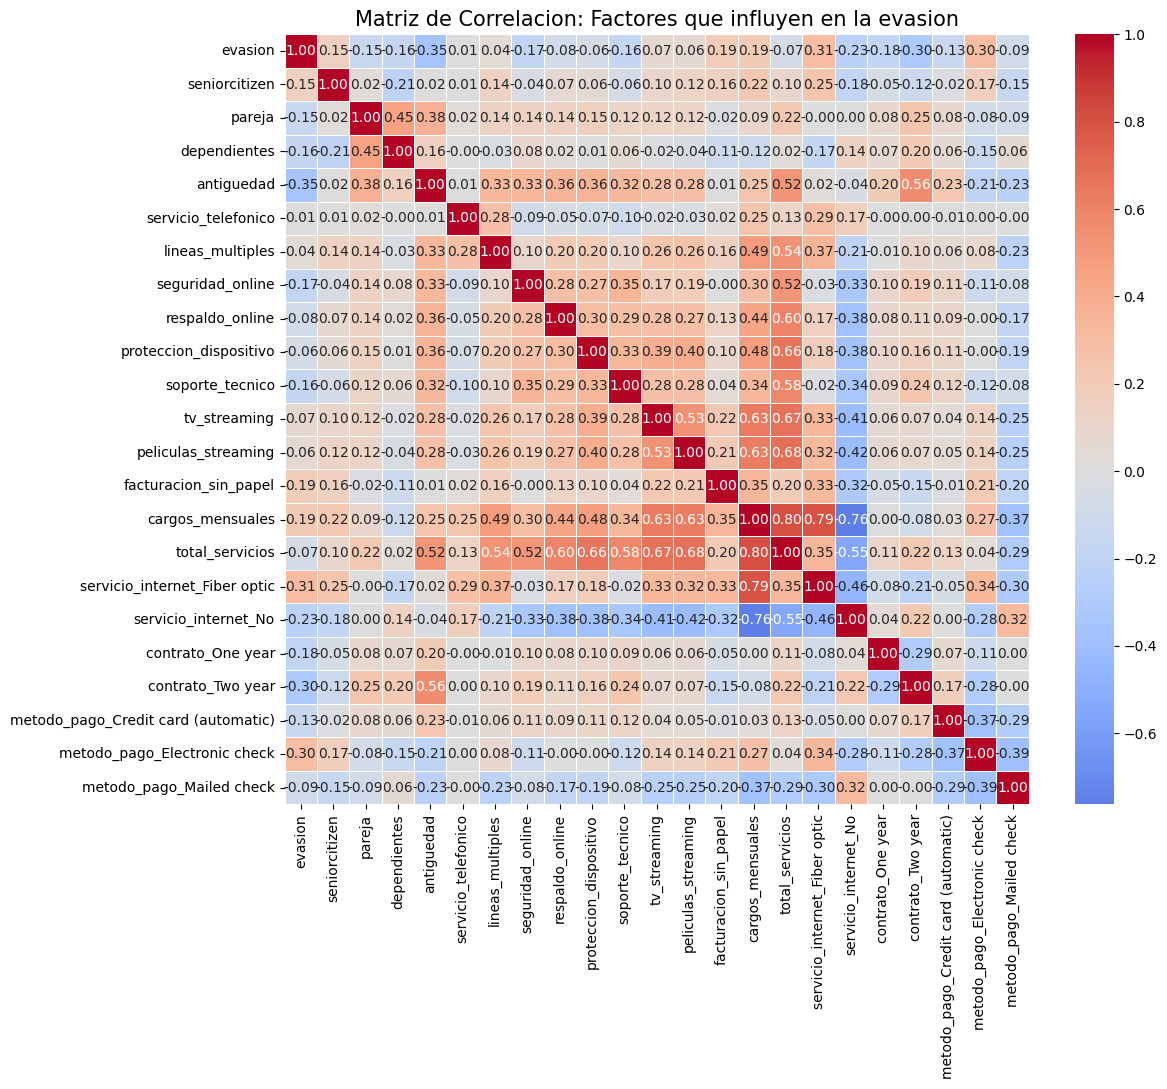

--- Correlación de cada variable con la Evasión ---
evasion                                1.000000
servicio_internet_Fiber optic          0.308170
metodo_pago_Electronic check           0.301544
cargos_mensuales                       0.194508
facturacion_sin_papel                  0.190891
seniorcitizen                          0.151619
tv_streaming                           0.065032
peliculas_streaming                    0.063192
lineas_multiples                       0.041958
servicio_telefonico                    0.011323
proteccion_dispositivo                -0.064944
total_servicios                       -0.065291
respaldo_online                       -0.081092
metodo_pago_Mailed check              -0.092562
metodo_pago_Credit card (automatic)   -0.133666
pareja                                -0.149135
dependientes                          -0.163459
soporte_tecnico                       -0.163937
seguridad_online                      -0.170520
contrato_One year                   

In [14]:
df_numerico = df.select_dtypes(include=['number'])

matriz_corr = df_numerico.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f',linewidths=0.5, center=0)

plt.title('Matriz de Correlacion: Factores que influyen en la evasion', fontsize=15)
plt.show()

# 4. Extraemos específicamente la relación con la variable 'evasion'
correlacion_objetivo = matriz_corr['evasion'].sort_values(ascending=False)
print("--- Correlación de cada variable con la Evasión ---")
print(correlacion_objetivo)

## Análisis Dirigido

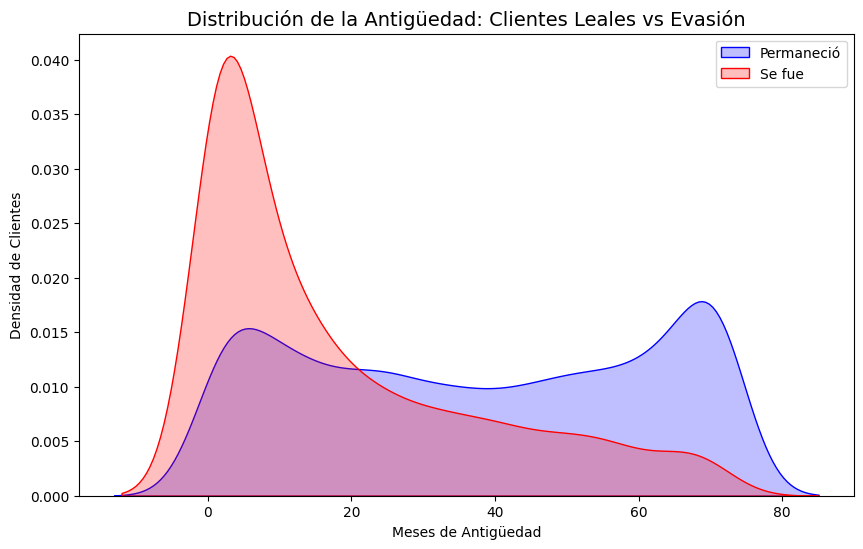

In [17]:
plt.figure(figsize=(10, 6))
# El KDE plot nos muestra la "densidad" o concentración de clientes
sns.kdeplot(df_copia[df_copia['evasion'] == 0]['antiguedad'], label='Permaneció', fill=True, color='blue')
sns.kdeplot(df_copia[df_copia['evasion'] == 1]['antiguedad'], label='Se fue', fill=True, color='red')

plt.title('Distribución de la Antigüedad: Clientes Leales vs Evasión', fontsize=14)
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Densidad de Clientes')
plt.legend()
plt.show()

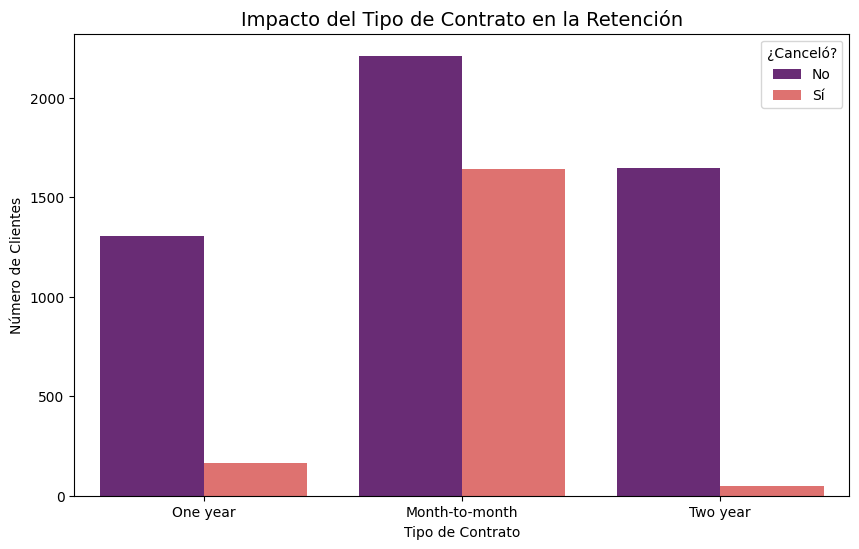

In [18]:
plt.figure(figsize=(10, 6))
# Usamos el DataFrame antes del One-Hot Encoding para ver las etiquetas claras
sns.countplot(x='contrato', hue='evasion', data=df_copia, palette='magma')

plt.title('Impacto del Tipo de Contrato en la Retención', fontsize=14)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.legend(title='¿Canceló?', labels=['No', 'Sí'])
plt.show()

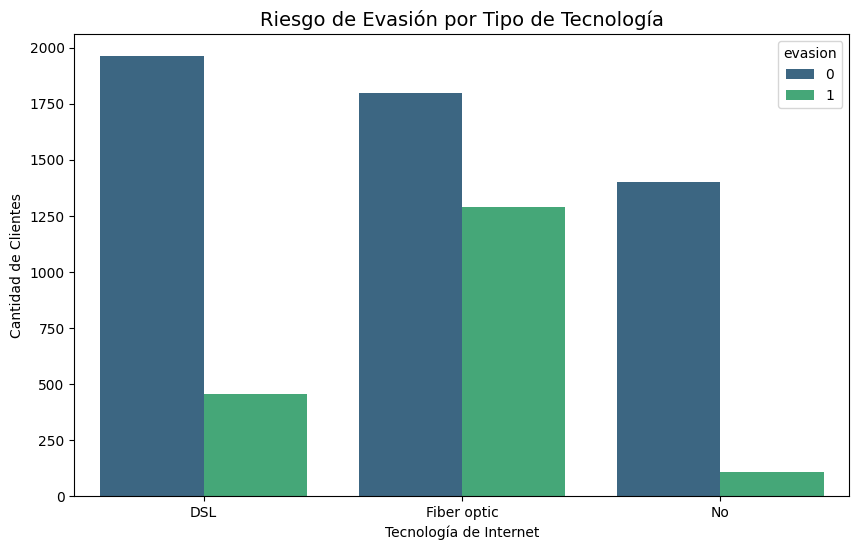

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='servicio_internet', hue='evasion', data=df_copia, palette='viridis')

plt.title('Riesgo de Evasión por Tipo de Tecnología', fontsize=14)
plt.xlabel('Tecnología de Internet')
plt.ylabel('Cantidad de Clientes')
plt.show()

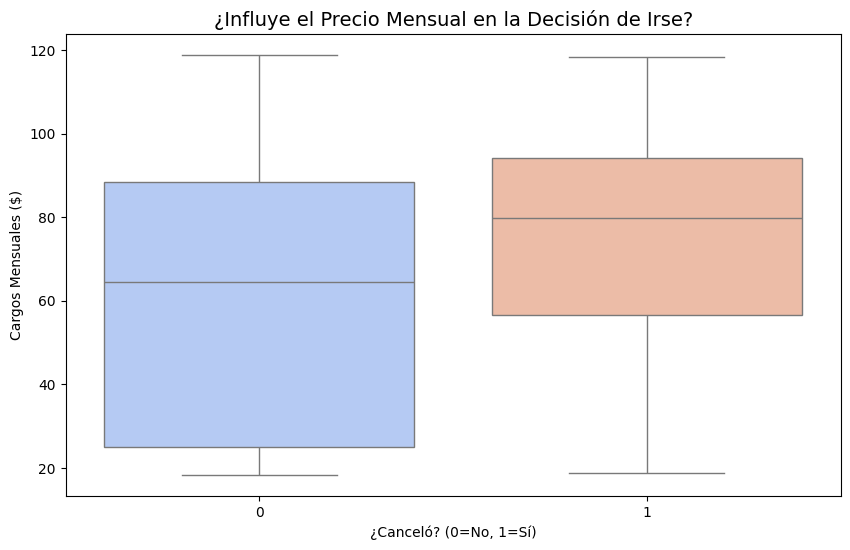

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='evasion', y='cargos_mensuales', hue='evasion', data=df_copia, palette='coolwarm', legend=False)

plt.title('¿Influye el Precio Mensual en la Decisión de Irse?', fontsize=14)
plt.xlabel('¿Canceló? (0=No, 1=Sí)')
plt.ylabel('Cargos Mensuales ($)')
plt.show()

## Creación de Modelos


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Usamos los datos ESCALADOS que creamos anteriormente
modelo_log = LogisticRegression(random_state=42)
modelo_log.fit(x_train_scaled, y_train_res)

# Predicción
y_pred_log = modelo_log.predict(x_test_scaled)

print("--- EVALUACIÓN: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

--- EVALUACIÓN: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.57      0.69      0.62       372

    accuracy                           0.78      1405
   macro avg       0.73      0.75      0.74      1405
weighted avg       0.80      0.78      0.79      1405



In [27]:
from sklearn.ensemble import RandomForestClassifier

# Para este modelo, usaremos los datos SIN ESCALAR (pero sí balanceados con SMOTE)
# X_train_res contiene los datos originales después de borrar 'diarias' y 'cargos_totales'
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(x_train_res, y_train_res)

# Predicción (usamos el X_test original, no el escalado)
y_pred_rf = modelo_rf.predict(x_test)

print("--- EVALUACIÓN: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- EVALUACIÓN: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1033
           1       0.54      0.54      0.54       372

    accuracy                           0.76      1405
   macro avg       0.69      0.69      0.69      1405
weighted avg       0.76      0.76      0.76      1405



¿Cuál modelo tuvo el mejor desempeño?
 
La Regresión Logística es la clara ganadora para este caso de uso.

Supera al Random Forest en todas las métricas críticas para la detección de evasión.

Regresión Logística: Muestra un comportamiento equilibrado. Al ser un modelo lineal, generaliza bien los patrones de lealtad (antigüedad) y riesgo (cargos mensuales) que vimos en la matriz de correlación. No hay signos evidentes de overfitting en los resultados de prueba.

Random Forest: Los resultados sugieren un posible Underfitting o falta de optimización.

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Usaremos el mismo GridSearchCV pero esta vez con los datos ESCALADOS
# para ver si el modelo logra capturar mejor los patrones de TelecomX
# 1. Definimos la rejilla de parámetros a probar
param_grid = {
    'n_estimators': [100, 200],          # Número de árboles
    'max_depth': [10, 20, None],         # Profundidad para evitar sobreajuste
    'min_samples_split': [2, 5, 10],     # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],       # Mínimo de muestras en cada "hoja"
    'bootstrap': [True, False]           # Método de selección de muestras
}
# 1. Configurar el modelo con pesos balanceados
rf_optimizado = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Reutilizamos la rejilla de parámetros (param_grid) anterior
grid_search_scaled = GridSearchCV(estimator=rf_optimizado, param_grid=param_grid, 
                                  cv=5, scoring='recall', n_jobs=-1)

# 3. ¡ENTRENAMOS CON DATOS ESCALADOS!
grid_search_scaled.fit(x_train_scaled, y_train_res)

# 4. Evaluamos el mejor resultado
mejor_rf_scaled = grid_search_scaled.best_estimator_
y_pred_rf_final = mejor_rf_scaled.predict(x_test_scaled)

print("--- EVALUACIÓN: RANDOM FOREST (ESCALADO + OPTIMIZADO) ---")
print(classification_report(y_test, y_pred_rf_final))

--- EVALUACIÓN: RANDOM FOREST (ESCALADO + OPTIMIZADO) ---
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.68      0.61       372

    accuracy                           0.77      1405
   macro avg       0.72      0.74      0.73      1405
weighted avg       0.79      0.77      0.78      1405



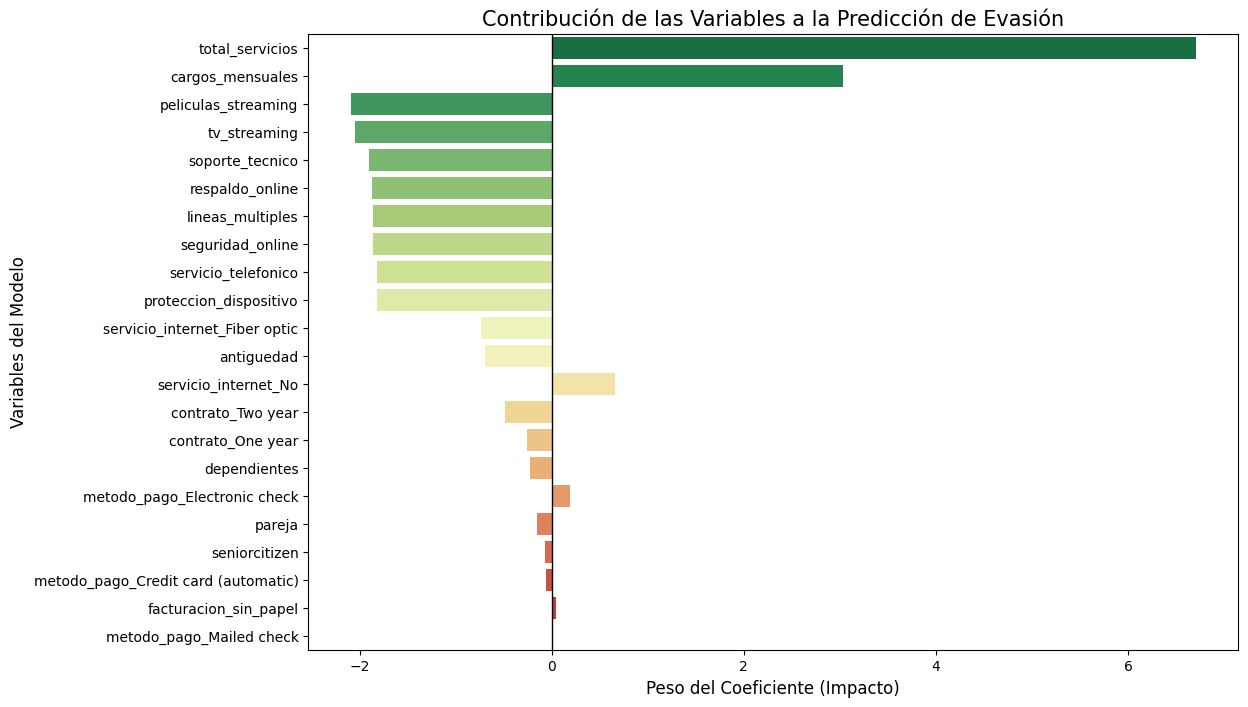

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer los coeficientes y los nombres de las columnas
importancia_log = pd.DataFrame({
    'Variable': x.columns,
    'Coeficiente': modelo_log.coef_[0]
})

# 2. Ordenar por valor absoluto para ver qué variable influye más
importancia_log['Abs_Coeficiente'] = importancia_log['Coeficiente'].abs()
importancia_log = importancia_log.sort_values(by='Abs_Coeficiente', ascending=False)

# 3. Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Coeficiente', y='Variable', hue='Variable', legend=False, data=importancia_log, palette='RdYlGn_r')

plt.title('Contribución de las Variables a la Predicción de Evasión', fontsize=15)
plt.xlabel('Peso del Coeficiente (Impacto)', fontsize=12)
plt.ylabel('Variables del Modelo', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea neutral
plt.show()

Los Modelos:

Regresión Logística (Ganador): Logró un Recall de 0.69, lo que significa que detecta al 69% de los clientes que realmente se van. Es el modelo más equilibrado y fácil de explicar.

Random Forest: Tras ajustarlo, alcanzó un Recall de 0.68. Aunque es potente, la relación de los datos es mayormente lineal, por lo que la logística funciona un poco mejor aquí.

Los "Culpables" de la Fuga

El modelo identificó patrones claros que empujan a los clientes a cancelar:

El Primer Año: El riesgo es máximo en los primeros 10 meses de antigüedad.

Flexibilidad Peligrosa: Los contratos mes a mes concentran casi todas las cancelaciones.

El Factor Precio: Clientes con facturas de $80 o más tienen una tendencia de fuga mucho mayor.

Complejidad y Pagos: Tener demasiados servicios acumulados (total_servicios) y pagar con cheque electrónico son señales de alerta críticas.

Plan de Acción: Estrategias de Retención

Para reducir la evasión en TelecomX, las prioridades deben ser:

Blindaje de Clientes Nuevos: Ofrecer beneficios especiales durante los primeros 12 meses para asegurar la lealtad inicial.

Migración de Contratos: Incentivar el paso de "mes a mes" hacia contratos anuales mediante descuentos.

Automatización: Promover el pago automático para eliminar la fricción del cheque electrónico.

Servicios de Valor: Impulsar el soporte técnico y la seguridad online, ya que actúan como "anclas" que reducen el abandono.